<a href="https://colab.research.google.com/github/JaySharma424/Data-Science/blob/main/KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Data/Machine_Learning/CLASSIFICATION/diabetes.csv')

In [18]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [19]:
df.isnull()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
763,False,False,False,False,False,False,False,False,False
764,False,False,False,False,False,False,False,False,False
765,False,False,False,False,False,False,False,False,False
766,False,False,False,False,False,False,False,False,False


In [20]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [22]:
df.duplicated().sum()

np.int64(0)

In [23]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [24]:

X = df.drop('Outcome', axis=1)
y = df['Outcome']

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

# import matrix
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score

In [119]:
from sklearn.preprocessing import StandardScaler
scaled_X = StandardScaler().fit_transform(X)

In [120]:
# from sklearn.decomposition import PCA
# pca = PCA(n_components=3)
# principalComponents = pca.fit_transform(scaled_X)

In [121]:
X_train, X_test, Y_train, Y_test = train_test_split(scaled_X, y, test_size=0.2, random_state=42, stratify=y)

In [122]:
X_train.shape, Y_train.shape, X_test.shape, Y_test.shape

((614, 8), (614,), (154, 8), (154,))

In [123]:
#Setup arrays to store training and test accuracies
neighbors = np.arange(1,20)
train_accuracy =np.empty(len(neighbors))
test_accuracy = np.empty(len(neighbors))

for i,k in enumerate(neighbors):
    # Setup a knn classifier with k neighbors
    knn = KNeighborsClassifier(n_neighbors=k)

    # Fit the model
    knn.fit(X_train, Y_train)

    # Compute accuracy on the training set
    train_accuracy[i] = knn.score(X_train, Y_train)

    # Compute accuracy on the test set
    test_accuracy[i] = knn.score(X_test, Y_test)

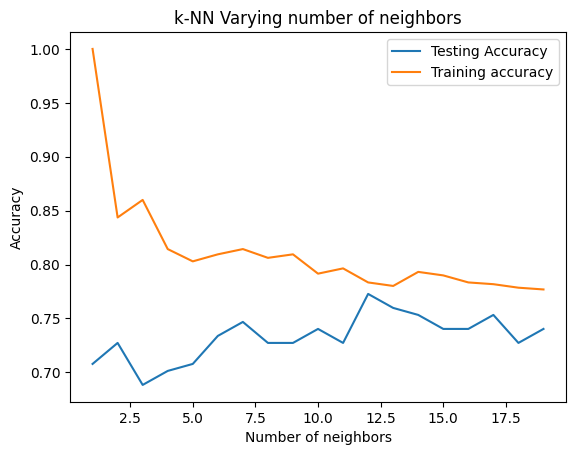

In [124]:

# Generate plot
plt.title('k-NN Varying number of neighbors')
plt.plot(neighbors, test_accuracy, label='Testing Accuracy')
plt.plot(neighbors, train_accuracy, label='Training accuracy')
plt.legend()
plt.xlabel('Number of neighbors')
plt.ylabel('Accuracy')
plt.show()

In [125]:
y_pred = knn.predict(X_test)

In [126]:
accuracy_score(Y_test, y_pred)

0.7402597402597403

randomized search

In [127]:
from sklearn.model_selection import RandomizedSearchCV
# Define the range for n_neighbors
n_neighbors_range = np.arange(1, 21) # A reasonable range for n_neighbors
pram_grid = {'n_neighbors': n_neighbors_range}
knn = KNeighborsClassifier()
knn_cv= RandomizedSearchCV(knn,pram_grid,cv=5)
knn_cv.fit(scaled_X,y)

RandomizedSearchCV(cv=5, estimator=KNeighborsClassifier(),
                   param_distributions={'n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20])})

In [128]:
best_params_ = knn_cv.best_params_

In [129]:
knn_cv.best_score_

np.float64(0.7669892199303965)

In [130]:
best_params_

{'n_neighbors': np.int64(17)}